<a href="https://colab.research.google.com/github/mahaapoorani/Machine-Learning-Projects/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
from sklearn.datasets import load_breast_cancer
data= load_breast_cancer()
X= pd.DataFrame(data.data, columns= data.feature_names)
y=data.target
print(X.shape)

(569, 30)


In [6]:
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

In [7]:
print(X_scaled.shape)

(569, 30)


In [8]:
pca = PCA(n_components=2)
X_pca= pca.fit_transform(X_scaled)

In [9]:
print(X_pca.shape)

(569, 2)


In [12]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print(pca_df.head())

        PC1        PC2
0  9.192837   1.948583
1  2.387802  -3.768172
2  5.733896  -1.075174
3  7.122953  10.275589
4  3.935302  -1.948072


In [10]:
print(pca.explained_variance_ratio_)

[0.44272026 0.18971182]


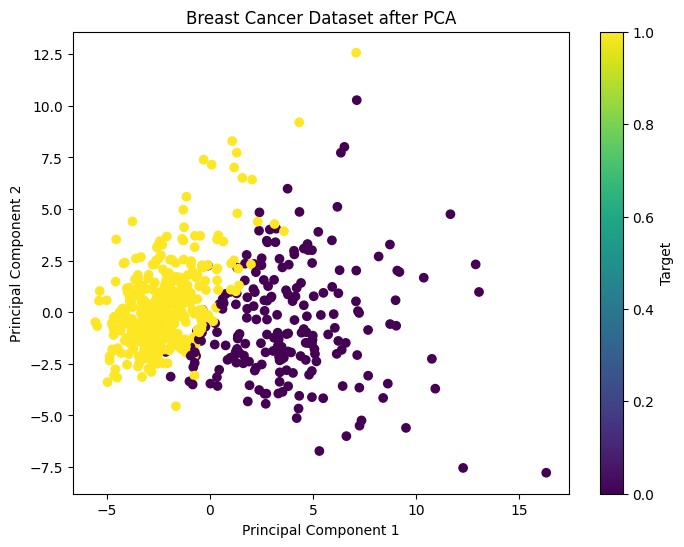

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Dataset after PCA")

plt.colorbar(label="Target")

plt.show()

In [14]:
print("Original Dataset")
print(X.head())

print("\n")

print("Dataset After PCA")
print(pca_df.head())

Original Dataset
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimete

In [16]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

print(cumulative_variance)

[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]


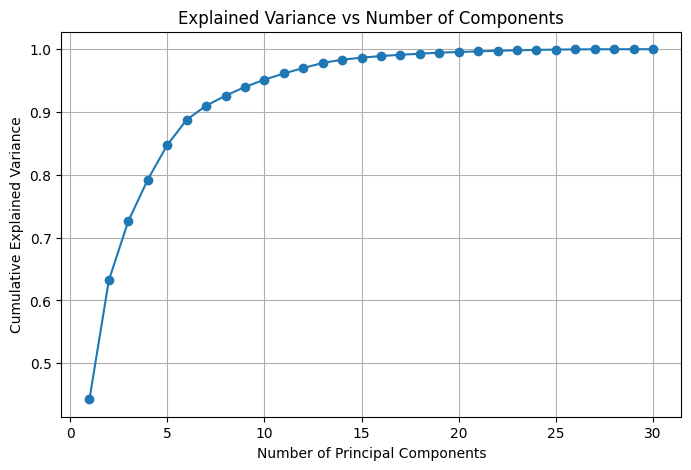

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Explained Variance vs Number of Components")

plt.grid()

plt.show()